In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import load_data, plot_data, sig, map_feature, plot_decision_boundary
from public_tests import *

In [3]:
# Load the first dataset (admissions data)
X_train, y_train = load_data("data/ex2data1.txt")

print('First five examples from X_train are:\n', X_train[:5])
print('First five examples from y_train are:\n', y_train[:5])


First five examples from X_train are:
 [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
First five examples from y_train are:
 [0. 0. 0. 1. 1.]


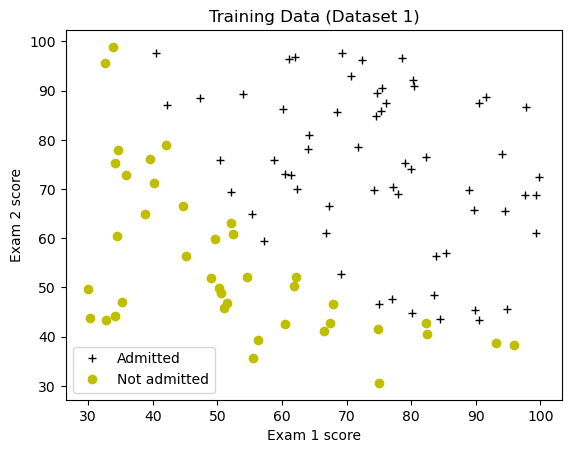

In [4]:
# Plot positive (admitted) and negative (not admitted) examples
plot_data(X_train, y_train)
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(['Admitted', 'Not admitted'])
plt.title('Training Data (Dataset 1)')
plt.show()


In [5]:
# Define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Run the public test to verify correctness
sigmoid_test(sigmoid)


All tests passed!


In [6]:
# Compute logistic regression cost (no regularization)
def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)
    cost = (-1 / m) * np.sum(y * np.log(f_wb) + (1 - y) * np.log(1 - f_wb))
    return cost

# Run the public test to check output
compute_cost_test(compute_cost)


All tests passed!


In [7]:
# Compute the gradient of the cost function
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)
    error = f_wb - y
    dj_dw = (1 / m) * np.dot(X.T, error)
    dj_db = (1 / m) * np.sum(error)
    return dj_db, dj_dw

# Run the public test to check gradients
compute_gradient_test(compute_gradient)


All tests passed!


In [8]:
# Run gradient descent optimization
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    w = w_in.copy()
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i < 100000:
            cost = compute_cost(X, y, w, b)
            J_history.append(cost)

        if i % (num_iters // 10) == 0:
            print(f"Iteration {i}: Cost {cost:.4f}")

    return w, b, J_history


In [9]:
initial_w = np.zeros(X_train.shape[1])
initial_b = 0.
iterations = 100000
alpha = 0.001

# Run gradient descent
w_out, b_out, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b, alpha, iterations)

print(f"Final weights (w): {w_out}")
print(f"Final bias (b): {b_out}")


Iteration 0: Cost 0.6983
Iteration 10000: Cost 0.5850
Iteration 20000: Cost 0.5473
Iteration 30000: Cost 0.5154
Iteration 40000: Cost 0.4883
Iteration 50000: Cost 0.4651
Iteration 60000: Cost 0.4451
Iteration 70000: Cost 0.4278
Iteration 80000: Cost 0.4126
Iteration 90000: Cost 0.3992
Final weights (w): [0.04528064 0.03819149]
Final bias (b): -4.811800271071584


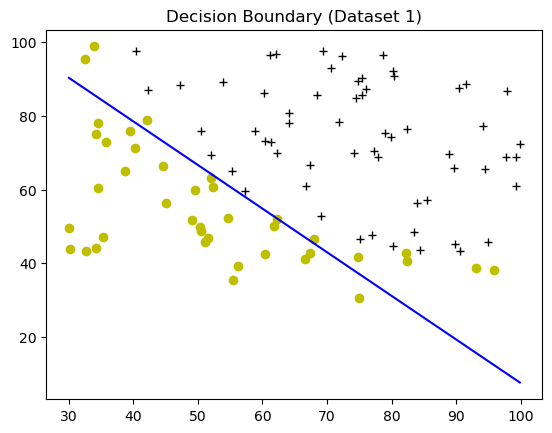

In [10]:
# Plot the learned decision boundary
plot_decision_boundary(w_out, b_out, X_train, y_train)
plt.title('Decision Boundary (Dataset 1)')
plt.show()


In [11]:
# Predict class labels using learned parameters
def predict(X, w, b):
    p = sigmoid(np.dot(X, w) + b)
    return (p >= 0.5).astype(int)

# Run the public test to verify predictions
predict_test(predict)


All tests passed!


In [12]:
p = predict(X_train, w_out, b_out)
accuracy = np.mean(p == y_train) * 100
print(f"Training Accuracy (Dataset 1): {accuracy:.2f}%")


Training Accuracy (Dataset 1): 91.00%


In [13]:
# Load second dataset and apply feature mapping
X_train2, y_train2 = load_data("data/ex2data2.txt")
X_mapped = map_feature(X_train2[:, 0], X_train2[:, 1])

print('Shape of mapped features:', X_mapped.shape)


Shape of mapped features: (118, 27)


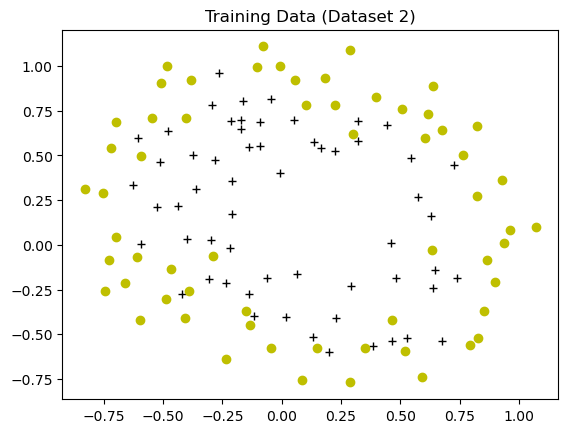

In [14]:
plot_data(X_train2, y_train2)
plt.title('Training Data (Dataset 2)')
plt.show()


In [15]:
# Compute cost with L2 regularization
def compute_cost_reg(X, y, w, b, lambda_):
    m = y.size
    cost = compute_cost(X, y, w, b)
    reg_cost = (lambda_ / (2 * m)) * np.sum(np.square(w))
    return cost + reg_cost

# Run the public test to verify
compute_cost_reg_test(compute_cost_reg)


All tests passed!


In [16]:
# Compute gradient with L2 regularization
def compute_gradient_reg(X, y, w, b, lambda_):
    m = y.size
    dj_db, dj_dw = compute_gradient(X, y, w, b)
    dj_dw = dj_dw + (lambda_ / m) * w
    return dj_db, dj_dw

# Run the public test to verify
compute_gradient_reg_test(compute_gradient_reg)


All tests passed!


In [17]:
initial_w = np.zeros(X_mapped.shape[1])
initial_b = 0.
lambda_ = 1
iterations = 100000
alpha = 0.01

# Run gradient descent
w_out, b_out, J_hist = gradient_descent(X_mapped, y_train2, initial_w, initial_b, alpha, iterations)

print(f"Final weights (w): {w_out}")
print(f"Final bias (b): {b_out}")


Iteration 0: Cost 0.6930
Iteration 10000: Cost 0.4512
Iteration 20000: Cost 0.3997
Iteration 30000: Cost 0.3770
Iteration 40000: Cost 0.3645
Iteration 50000: Cost 0.3567
Iteration 60000: Cost 0.3514
Iteration 70000: Cost 0.3475
Iteration 80000: Cost 0.3446
Iteration 90000: Cost 0.3423
Final weights (w): [ 2.30609539  3.56885346 -5.02833654 -4.1111655  -4.98247361  1.02421189
 -1.50817941 -0.94834424 -0.33271122 -4.10499811  0.28791358 -2.18810116
 -1.54638114 -3.37367521 -0.60856335 -0.70799397  0.42613833 -1.29118488
 -1.49518123 -0.24580857 -3.25835604  0.37348512 -0.97043443  0.29463692
 -1.30711547 -1.14329517 -1.68067308]
Final bias (b): 3.252450549575588


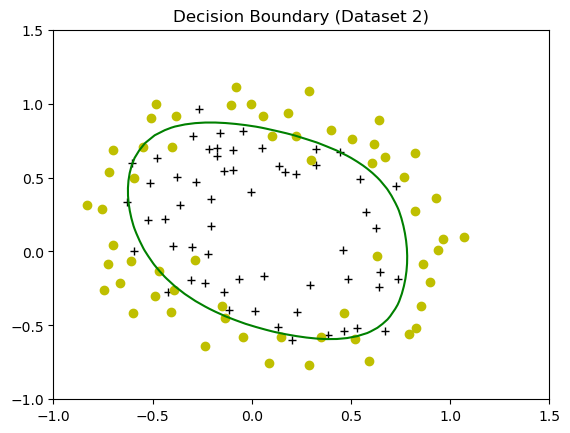

In [18]:
plot_decision_boundary(w_out, b_out, X_mapped, y_train2)
plt.title('Decision Boundary (Dataset 2)')
plt.show()


In [19]:
p = predict(X_mapped, w_out, b_out)
accuracy = np.mean(p == y_train2) * 100
print(f"Training Accuracy (Dataset 2): {accuracy:.2f}%")


Training Accuracy (Dataset 2): 83.90%
